# Non-negative least squares

在这个例子中，我们拟合了一个对回归系数施加非负约束的线性模型并将其得到的系数估计值与传统线性回归模型做对比。

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import r2_score

生成一些随机数据

In [14]:
np.random.seed(42)

n_samples, n_features = 200, 50
X = np.random.randn(n_samples, n_features)
true_coef = 3 * np.random.randn(n_features)
#Threshold coefficients to render them non-negative
true_coef[true_coef < 0] = 0
y = np.dot(X, true_coef)

#Add some noise
y += 5 * np.random.normal(size=(n_samples,))

划分数据为训练集和测试集

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

拟合非负最小二乘法

In [16]:
from sklearn.linear_model import LinearRegression

reg_nnls = LinearRegression(positive=True)
y_pred_nnls = reg_nnls.fit(X_train, y_train).predict(X_test)
r2_score_nnls = r2_score(y_test, y_pred_nnls)
print("NNLS R2 score", r2_score_nnls)

NNLS R2 score 0.8225220806196526


拟合一个OLS

In [17]:
reg_ols = LinearRegression()
y_pred_ols = reg_ols.fit(X_train, y_train).predict(X_test)
r2_score_ols = r2_score(y_test, y_pred_ols)
print("OLS R2 score", r2_score_ols)

OLS R2 score 0.7436926291700354


对比普通最小二乘（OLS）与非负最小二乘（NNLS）的回归系数可以发现，两组系数高度相关（图中虚线代表等值参考线）；但非负约束会将部分系数压缩至 0。因此非负最小二乘天然能够生成稀疏解。

Text(0, 0.5, 'NNLS regression coefficients')

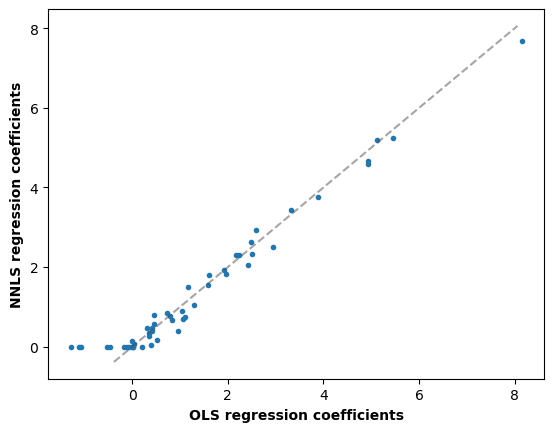

In [18]:
fig, ax = plt.subplots()
ax.plot(reg_ols.coef_, reg_nnls.coef_, linewidth=0, marker=".")

low_x, high_x = ax.get_xlim()
low_y, high_y = ax.get_ylim()
low = max(low_x, low_y)
high = min(high_x, high_y)
ax.plot([low, high], [low, high], ls="--", c=".3", alpha=0.5)
ax.set_xlabel("OLS regression coefficients", fontweight="bold")
ax.set_ylabel("NNLS regression coefficients", fontweight="bold")